<a href="https://colab.research.google.com/github/harsh23421/Data-Analysis-Project/blob/main/extreme%20weatherprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- 0. Generate Synthetic Dataset (For immediate use) ---
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', end='2023-12-31', freq='D')
n = len(dates)
temp = 15 + 10 * np.sin(2 * np.pi * np.arange(n) / 365) + np.random.normal(0, 3, n)
humidity = np.random.uniform(30, 90, n)
precip = np.random.exponential(2, n) * (np.random.random(n) > 0.8) # Occasional rain

df_weather = pd.DataFrame({
    'Date': dates,
    'Temperature': temp,
    'Humidity': humidity,
    'Precipitation': precip
})
# Introduce a few missing values for the "Cleaning" task
df_weather.loc[np.random.choice(df_weather.index, 5), 'Temperature'] = np.nan
df_weather.to_csv('weather_data.csv', index=False)

In [3]:
# --- 1. Load and Inspect Data ---
df = pd.read_csv('weather_data.csv')
print("--- First 5 Rows ---")
print(df.head())
print("\n--- Data Types ---")
print(df.dtypes)


--- First 5 Rows ---
         Date  Temperature   Humidity  Precipitation
0  2020-01-01    16.490142  30.559897       0.000000
1  2020-01-02    14.757341  44.800732       0.753250
2  2020-01-03    17.287282  73.587703       0.000000
3  2020-01-04    20.085286  89.508597       0.483921
4  2020-01-05    14.985564  35.950686       0.000000

--- Data Types ---
Date              object
Temperature      float64
Humidity         float64
Precipitation    float64
dtype: object


In [4]:
# --- 2. Data Cleaning ---
# Handle missing values (Fill with mean)
df['Temperature'] = df['Temperature'].fillna(df['Temperature'].mean())

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
# --- 3. Descriptive Statistics with NumPy ---
metrics = ['Temperature', 'Humidity', 'Precipitation']
stats = {
    'Mean': [np.mean(df[m]) for m in metrics],
    'Median': [np.median(df[m]) for m in metrics],
    'Std Dev': [np.std(df[m]) for m in metrics]
}
print("\n--- NumPy Statistics ---")
print(pd.DataFrame(stats, index=metrics))


--- NumPy Statistics ---
                    Mean     Median    Std Dev
Temperature    15.129912  15.129912   7.627353
Humidity       59.836118  60.006765  17.238267
Precipitation   0.393282   0.000000   1.196059


In [6]:
# --- 4. Monthly Analysis (Pandas GroupBy) ---
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')[metrics].mean()
print("\n--- Monthly Average Metrics ---")
print(monthly_avg)


--- Monthly Average Metrics ---
       Temperature   Humidity  Precipitation
Month                                       
1        17.616480  61.917480       0.435049
2        22.265588  56.884074       0.466725
3        24.464351  57.668180       0.296457
4        24.540333  59.335936       0.527342
5        22.207910  58.816288       0.387210
6        18.002555  59.936365       0.313963
7        12.666599  60.822075       0.395114
8         8.199216  60.079319       0.473475
9         5.163976  60.949307       0.388560
10        5.797721  59.766277       0.320999
11        8.420060  61.371947       0.272761
12       12.705460  60.296848       0.445974


/tmp/ipykernel_10455/1828125663.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_resampled = df.set_index('Date').resample('M').mean()


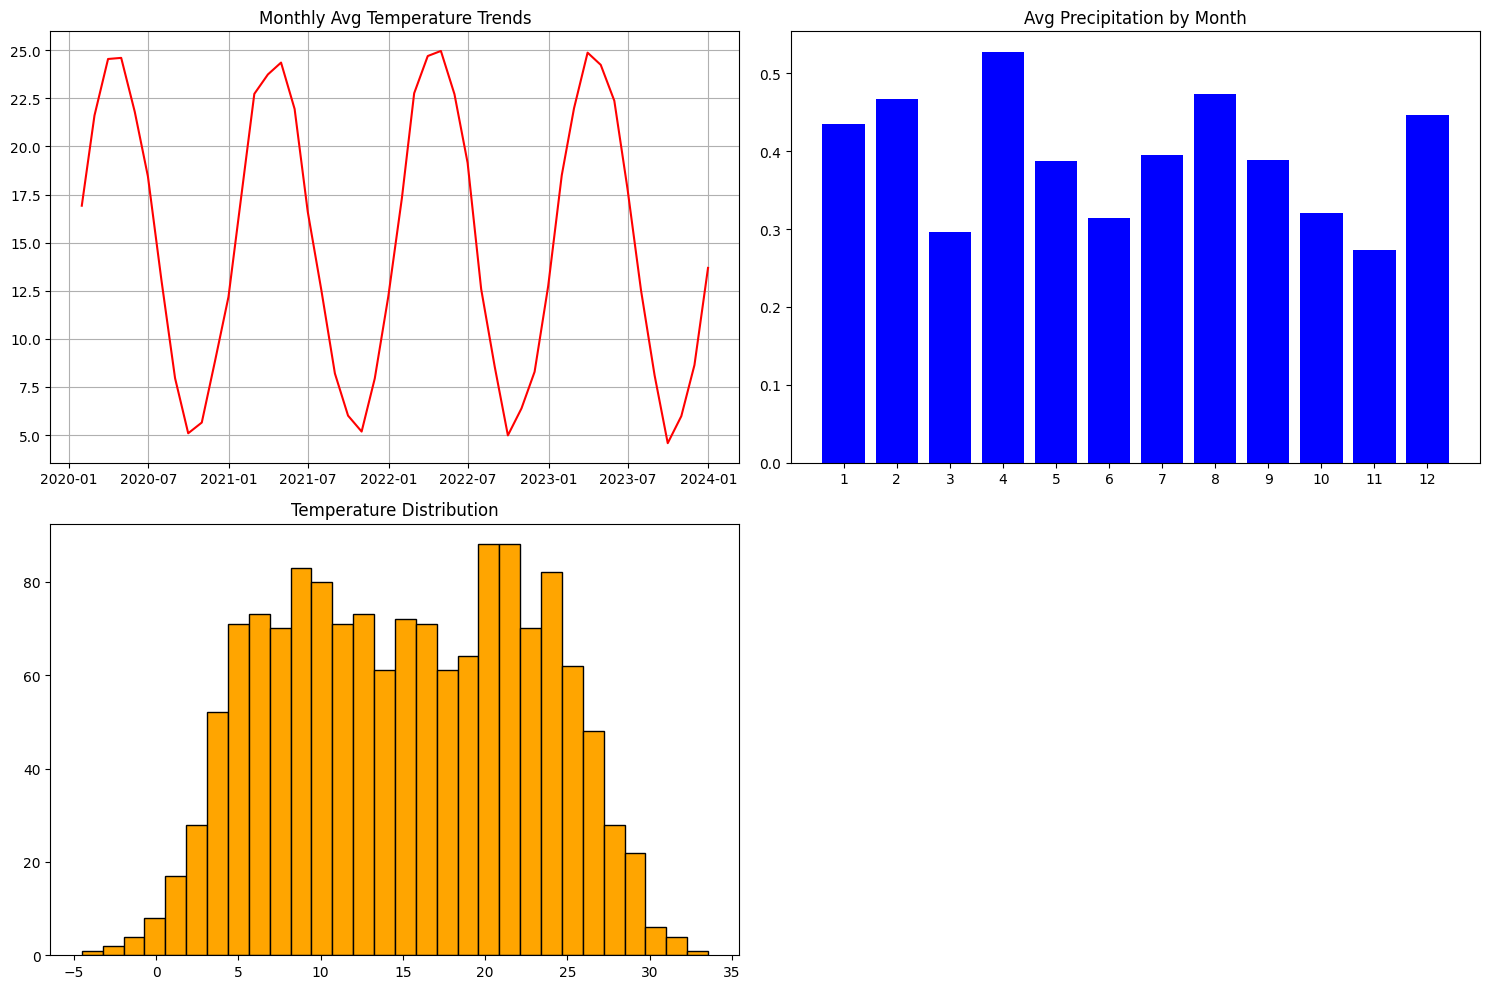

In [7]:
# --- 5. Visualizations with Matplotlib ---
plt.figure(figsize=(15, 10))

# Line Plot: Temperature Trends
plt.subplot(2, 2, 1)
df_resampled = df.set_index('Date').resample('M').mean()
plt.plot(df_resampled.index, df_resampled['Temperature'], color='red')
plt.title('Monthly Avg Temperature Trends')
plt.grid(True)

# Bar Plot: Precipitation by Month
plt.subplot(2, 2, 2)
plt.bar(monthly_avg.index, monthly_avg['Precipitation'], color='blue')
plt.title('Avg Precipitation by Month')
plt.xticks(range(1, 13))

# Histogram: Temp Distribution
plt.subplot(2, 2, 3)
plt.hist(df['Temperature'], bins=30, color='orange', edgecolor='black')
plt.title('Temperature Distribution')

plt.tight_layout()
plt.show()

In [8]:
# --- 6. Identify Extreme Weather (NumPy Filtering) ---
# Filter days where Temp > 2 Standard Deviations from mean
threshold = np.mean(df['Temperature']) + (2 * np.std(df['Temperature']))
extreme_days = df[df['Temperature'] > threshold]

print(f"\n--- Extreme Heat Days (Threshold: {threshold:.2f}) ---")
print(extreme_days[['Date', 'Temperature']].head())


--- Extreme Heat Days (Threshold: 30.38) ---
          Date  Temperature
113 2020-04-23    31.696966
460 2021-04-05    30.873347
478 2021-04-23    33.543882
822 2022-04-02    31.895861
847 2022-04-27    31.399458
